In [1]:
from imports_IBM_NM import *
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib as mpl
mpl.rc('text', usetex = True)
mpl.rc('font', family = 'serif')
colors_blais = ['#33658A','#86BBD8']

In [3]:
token = '2712985633675e074d63da9266dba7714d932b8e447f0f4632ca0965701237c6fb67854d65b3457cf7087e056cda6859748c77bd7721251cdaf17e9a1e30e6cc'
provider = qiskit_ibm_provider.IBMProvider(token)

In [4]:
instance = 'ibm-q/open/main'

device = 'sherbrooke'
backend_name = 'ibm_'+device # get_backend_name(device)
backend = provider.get_backend(backend_name, instance=instance)

In [5]:
n_qubits = backend.configuration().n_qubits
qubits = np.arange(n_qubits)

scan_backend(token, provider, device)
colors_gradient = get_color_gradient('#0000FF', '#FF0000', n_qubits)

(no-q) Device: sherbrooke
q = 0: T1 = 210us, T2 = 174us
q = 1: T1 = 386us, T2 = 265us
q = 2: T1 = 190us, T2 = 191us
q = 3: T1 = 422us, T2 = 212us
q = 4: T1 = 352us, T2 = 441us
q = 5: T1 = 271us, T2 = 317us
q = 6: T1 = 285us, T2 = 342us
q = 7: T1 = 78us, T2 = 238us
q = 8: T1 = 337us, T2 = 206us
q = 9: T1 = 397us, T2 = 65us
q = 10: T1 = 245us, T2 = 172us
q = 11: T1 = 393us, T2 = 71us
q = 12: T1 = 344us, T2 = 278us
q = 13: T1 = 379us, T2 = 211us
q = 14: T1 = 183us, T2 = 99us
q = 15: T1 = 330us, T2 = 443us
q = 16: T1 = 312us, T2 = 200us
q = 17: T1 = 248us, T2 = 69us
q = 18: T1 = 350us, T2 = 51us
q = 19: T1 = 452us, T2 = 129us
q = 20: T1 = 440us, T2 = 93us
q = 21: T1 = 356us, T2 = 28us
q = 22: T1 = 333us, T2 = 268us
q = 23: T1 = 352us, T2 = 434us
q = 24: T1 = 297us, T2 = 185us
q = 25: T1 = 273us, T2 = 496us
q = 26: T1 = 137us, T2 = 122us
q = 27: T1 = 383us, T2 = 107us
q = 28: T1 = 257us, T2 = 71us
q = 29: T1 = 463us, T2 = 182us
q = 30: T1 = 353us, T2 = 278us
q = 31: T1 = 236us, T2 = 33us
q 

In [3]:
token = '30f7a88371a599e8a02059450e16ecad23652218ba4d716a274b5f5ac703e4531f6a9612e0f3757035b15039f494697b00c0e34a1b533740ef23c1523782f45a'
provider = qiskit_ibm_provider.IBMProvider(token)

instance = 'ibm-q-research-2/johns-hopkins-un-3/main'

device = 'quito'
backend = provider.get_backend('ibmq_quito', instance=instance)
n_qubits = backend.configuration().n_qubits
qubits = np.arange(n_qubits)

scan_backend(token, provider, device)

(q) Device: quito
q = 0: T1 = 83us, T2 = 112us
q = 1: T1 = 85us, T2 = 40us
q = 2: T1 = 108us, T2 = 112us
q = 3: T1 = 144us, T2 = 19us
q = 4: T1 = 96us, T2 = 104us


In [6]:
# Define noise characterization protocols
qubit = 1
nc = noise_characterization(backend, qubit, m_FTTPS=4, num_T1=10, num_T2=10)
# nc.T1_time, nc.T2_time = device_avg_Ts(backend)
nc.T2_time, nc.T2_time = 200, 200

In [7]:
def gen_fpw_circuits(num_beta, step_beta):
    circs = []

    kk = np.arange(0,num_beta*step_beta, step_beta)
    for i in kk:
        circ = qk.QuantumCircuit(1,1)
        for _ in range(i):
            circ.x(0)
            circ.z(0)
            circ.x(0)
            circ.z(0)
        circ.measure(0,0)
        circs += [circ]
    return circs[1:]

# Gaussian pulse

In [8]:
def gaussian_pulse(x, mu, sig):
    gg = np.exp(-np.power(x - mu, 2.) / (2 * np.power(sig, 2.)))
    gg *= np.pi/np.sum(gg)/dt
    return gg

def constant_pulse(tt):
    return np.pi/len(tt)*np.ones(len(tt))

In [9]:
import scipy

paulis = [pauli_x, pauli_y, pauli_z]
X,Y,Z = paulis
rho_0 = np.array([[1,0],[0,0]])
v0 = [np.trace(rho_0@pauli) for pauli in paulis]

def Gmat(theta, alpha, beta, gamma, eps, dt):
    return np.array([[-alpha, -beta, 0],
                     [beta, -alpha , -theta*(1+eps)],
                     [0,theta*(1+eps), -gamma]])/dt

In [10]:
# def gaussian_pulse_zeroends(N,sigma,theta):
#     nn = np.arange(N+1)
#     exp_n = np.exp(-dt**2*(nn-N/2)**2/2/sigma)
#     exp = np.exp((dt*N/2)**2/2/sigma)
#     c = theta/dt/(N-np.sum(exp_n)*exp)
#     A = -c*exp
#     return (A*exp_n + c)[1:]*dt

def gaussian_pulse_zeroends(tt, sigma, theta):
    gg = gaussian_pulse(tt, tt[-1]/2, sigma)
    gg -= gg[0]
    gg *= np.pi/np.sum(gg)/tt[1]
    return gg

In [11]:
dt = 0.035555
Ndt = 160 
ddt = dt/Ndt
dtt = np.linspace(0,dt,Ndt, endpoint=False)
sigma = dt/4
print("σ = %.4f"%sigma)
# gg = gaussian_pulse(dtt,dt/2,sigma)
gg = gaussian_pulse_zeroends(dtt, sigma, np.pi)

σ = 0.0089


### Simulation

In [12]:
osc_fun = lambda t,b: (1+np.cos(2*b*t/np.pi*1.015))/2

In [13]:
psi0 = np.array([1,0])
psi1 = np.array([0,1])
psip = np.array([1,1])/np.sqrt(2)

rho0 = np.outer(psi0,psi0)
rho1 = np.outer(psi1,psi1)
rhop = np.outer(psip,psip)

In [14]:
K = 200
K_step = 2
kk = np.arange(0,K,K_step)
tt = kk*2*dt

In [15]:
beta = 2 # MHz

H = beta*Z/2 + np.pi/dt*X/2
Uconst = sc.linalg.expm(-1j*H*dt)

Ugauss = np.identity(2)
for g in gg:
    h = beta*Z/2 + g*X/2
    Ugauss = sc.linalg.expm(-1j*h*ddt)@Ugauss

In [16]:
ps_const = []
rho = rho0
for _ in kk:
    for _ in range(K_step):
        rho = Uconst@rho@Uconst.T.conj()
        rho = Z@rho@Z
        rho = Uconst@rho@Uconst.T.conj()
        rho = Z@rho@Z
    ps_const += [rho[0,0].real]
    
ps_gauss = []
rho = rho0
for _ in kk:
    for _ in range(K_step):
        rho = Ugauss@rho@Ugauss.T.conj()
        rho = Z@rho@Z
        rho = Ugauss@rho@Ugauss.T.conj()
        rho = Z@rho@Z
    ps_gauss += [rho[0,0].real]

beta:       2.00
beta_const: 2.00
beta_gauss: 1.31


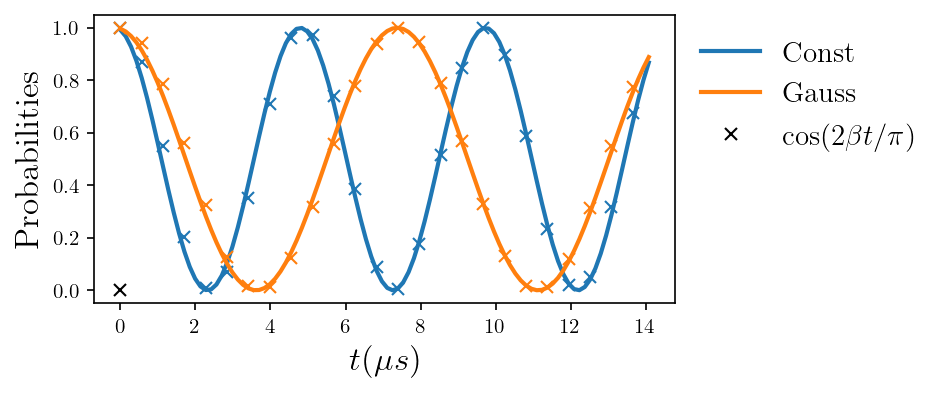

In [17]:
print("beta:       %.2f"%beta)
plt.figure(dpi=150, figsize=(5,2.5))

# Constant pulse
plt.plot(tt, ps_const, color=colors[0], lw=2, label='Const')
(beta_const), cov = spopt.curve_fit(osc_fun, tt, ps_const, p0=(beta))
print("beta_const: %.2f" % beta_const)
plt.plot(tt[::4], osc_fun(tt[::4], beta_const), color=colors[0], marker='x', ls='')

# Gaussian pulse
plt.plot(tt, ps_gauss, color=colors[1], lw=2, label='Gauss')
(beta_gauss), cov = spopt.curve_fit(osc_fun, tt, ps_gauss, p0=(2*beta/np.pi))
print("beta_gauss: %.2f" % beta_gauss)
plt.plot(tt[::4], osc_fun(tt[::4], beta_gauss), color=colors[1], marker='x', ls='')

plt.plot(0,0, marker='x', color='k', ls='', label=r'$\cos(2\beta t/\pi)$')

plt.ylabel('Probabilities', size=16)
plt.xlabel('$t (\mu s)$', size=16)
plt.legend(frameon=False, bbox_to_anchor=(1,1), fontsize=14)
plt.show()

# Iterate over $\beta$

In [18]:
def get_Us(beta):
    H = beta*Z/2 + np.pi/dt*X/2
    Uconst = sc.linalg.expm(-1j*H*dt)

    Ugauss = np.identity(2)
    for g in gg:
        h = beta*Z/2 + g*X/2
        Ugauss = sc.linalg.expm(-1j*h*ddt)@Ugauss
    
    return Uconst,Ugauss

In [19]:
def get_ps(beta):
    Uconst,Ugauss = get_Us(beta)
    
    ps_const = []
    rho = rho0
    for _ in kk:
        for _ in range(K_step):
            rho = Uconst@rho@Uconst.T.conj()
            rho = Z@rho@Z
            rho = Uconst@rho@Uconst.T.conj()
            rho = Z@rho@Z
        ps_const += [rho[0,0].real]

    ps_gauss = []
    rho = rho0
    for _ in kk:
        for _ in range(K_step):
            rho = Ugauss@rho@Ugauss.T.conj()
            rho = Z@rho@Z
            rho = Ugauss@rho@Ugauss.T.conj()
            rho = Z@rho@Z
        ps_gauss += [rho[0,0].real]
    
    return ps_const, ps_gauss

In [20]:
betas = np.linspace(0.5,5,10)

ps_const = {}
ps_gauss = {}

for beta in betas:
    ps_const[beta], ps_gauss[beta] = get_ps(beta)

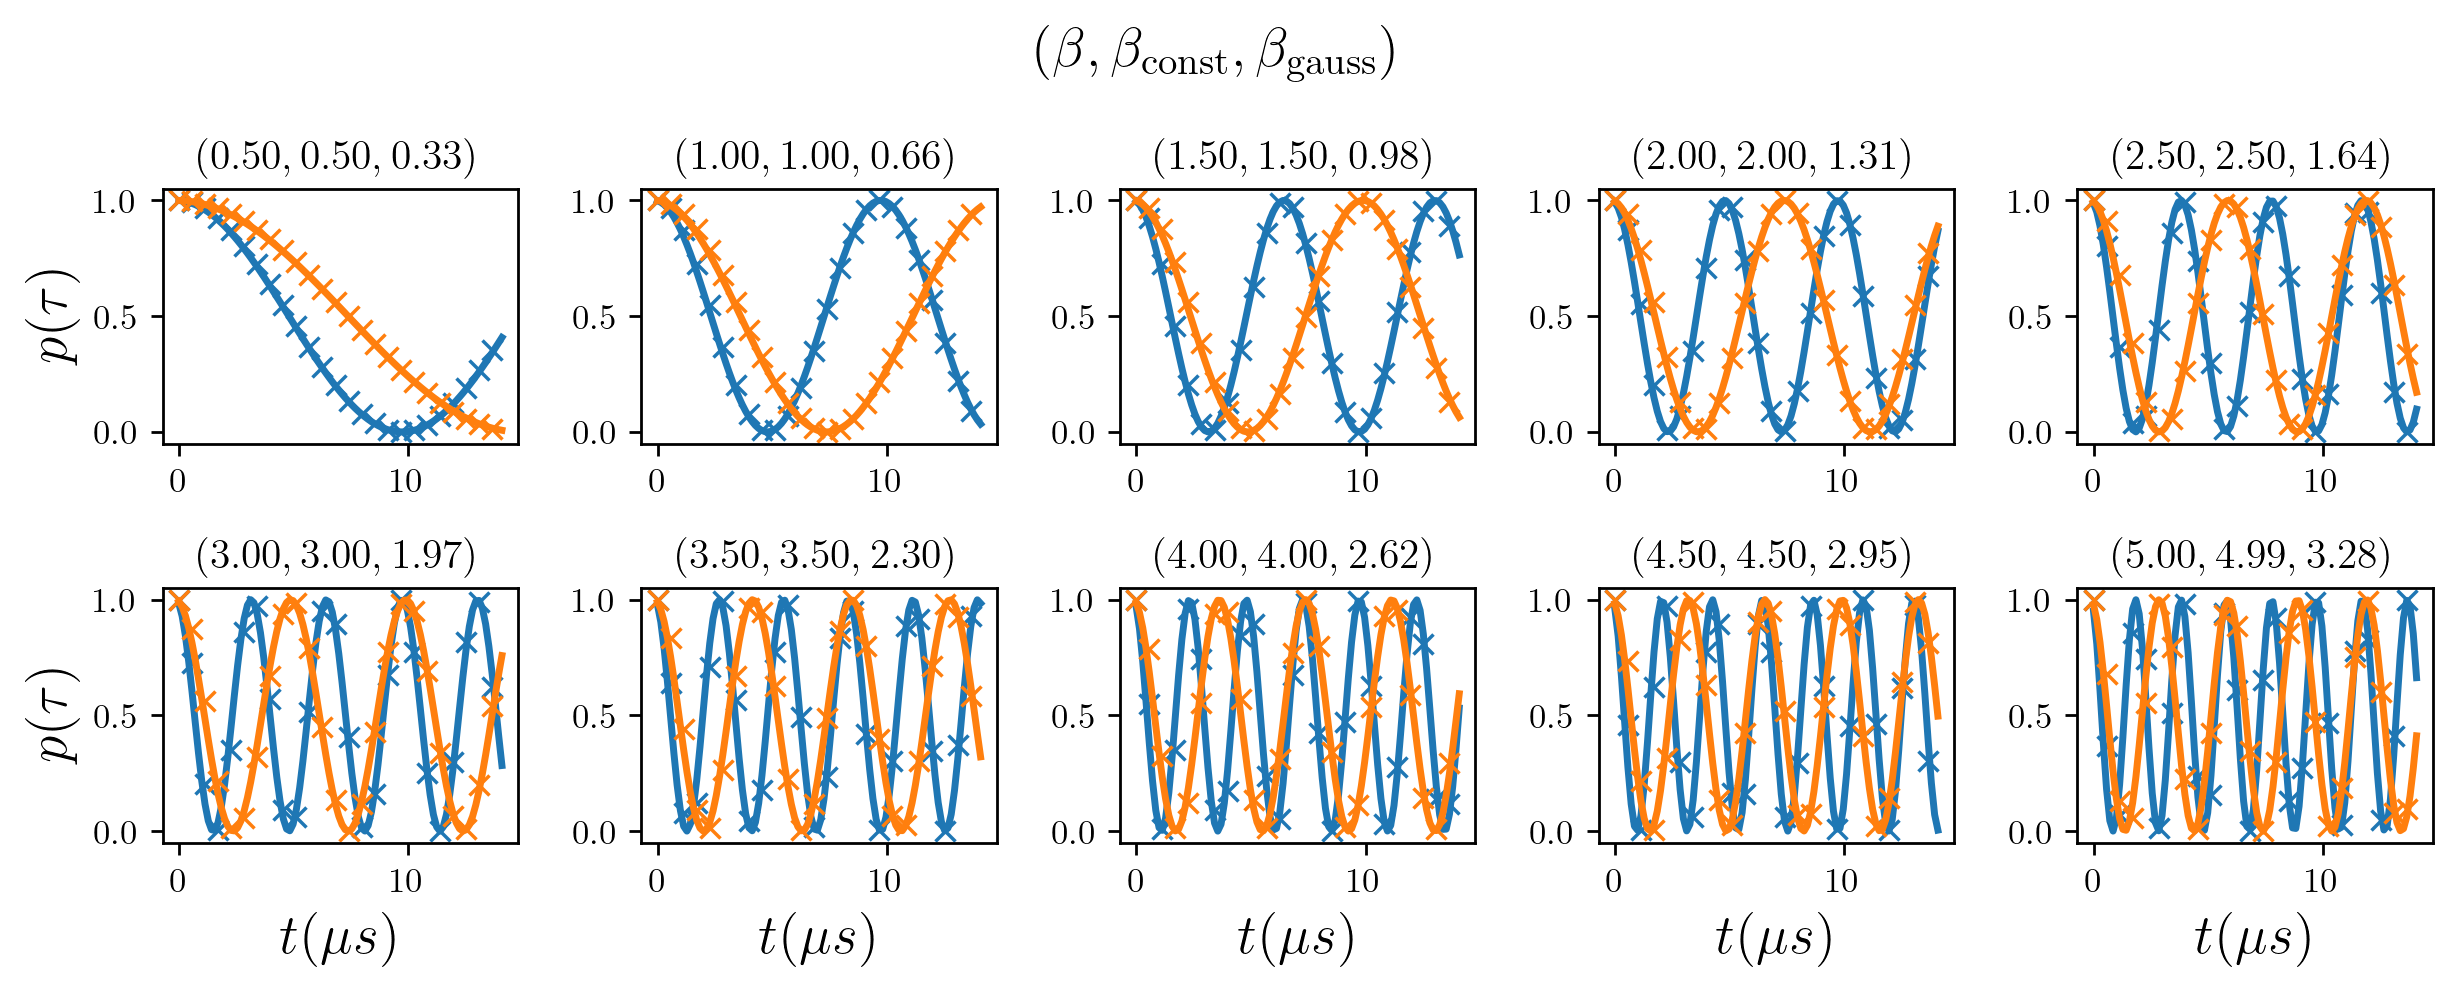

In [21]:
noise_num = len(betas)

beta_const_list = []
beta_gauss_list = []

fig = plt.figure(dpi=250, figsize=(10,4))
plt.suptitle(r"$(\beta,\beta_{\mathrm{const}},\beta_{\mathrm{gauss}})$", fontsize=16)
for i,beta in enumerate(betas):
    ax = fig.add_subplot(2, noise_num//2, i+1)

    # Constant pulse
    plt.plot(tt, ps_const[beta], color=colors[0], lw=2, label='Const')
    (beta_const), cov = spopt.curve_fit(osc_fun, tt, ps_const[beta], p0=(beta))
    plt.plot(tt[::4], osc_fun(tt[::4], beta_const), color=colors[0], marker='x', ls='')

    # Gaussian pulse
    plt.plot(tt, ps_gauss[beta], color=colors[1], lw=2, label='Gauss')
    (beta_gauss), cov = spopt.curve_fit(osc_fun, tt, ps_gauss[beta], p0=(2*beta/np.pi))
    plt.plot(tt[::4], osc_fun(tt[::4], beta_gauss), color=colors[1], marker='x', ls='')

    ax.set_title('$(%.2f,%.2f,%.2f)$'%(beta,beta_const,beta_gauss), fontsize=12)
    beta_const_list += [beta_const[0]]
    beta_gauss_list += [beta_gauss[0]]
    
    ax.set_ylim(-0.05,1.05)
    if i>noise_num//2-1:
        ax.set_xlabel('$t (\mu s)$', size=16)
    if (i%(noise_num//2))==0:
        ax.set_ylabel(r'$p(\tau)$', size=16)
plt.tight_layout()
plt.show()

# Different $\beta$'s

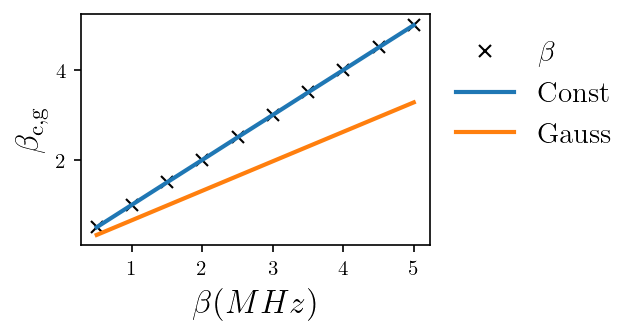

In [22]:
# print("beta:       %.2f"%beta)
plt.figure(dpi=150, figsize=(3,2))

plt.plot(betas, betas, marker='x', label=r'$\beta$', color='k', ls='')
plt.plot(betas, beta_const_list, color=colors[0], lw=2, label='Const')
plt.plot(betas, beta_gauss_list, color=colors[1], lw=2, label='Gauss')

plt.ylabel(r'$\beta_{\mathrm{c,g}}$', size=16)
plt.xlabel(r'$\beta (MHz)$', size=16)
plt.legend(frameon=False, bbox_to_anchor=(1,1), fontsize=14)
plt.show()

In [23]:
ratio = np.mean(betas/np.array(beta_gauss_list))
print("Ratio between Gauss and beta: %.2f" % ratio)

Ratio between Gauss and beta: 1.52


In [24]:
np.pi/2

1.5707963267948966

# Fitting with pulse shape correction

<font size="4">
    $$\cos\left(\frac{2}{\pi} \beta t\right) \longrightarrow \cos\left(\frac{4}{3\pi} \beta t\right)$$

In [25]:
osc_fun_gauss = lambda t,b: (1+np.cos(4*b*t/np.pi/3))/2

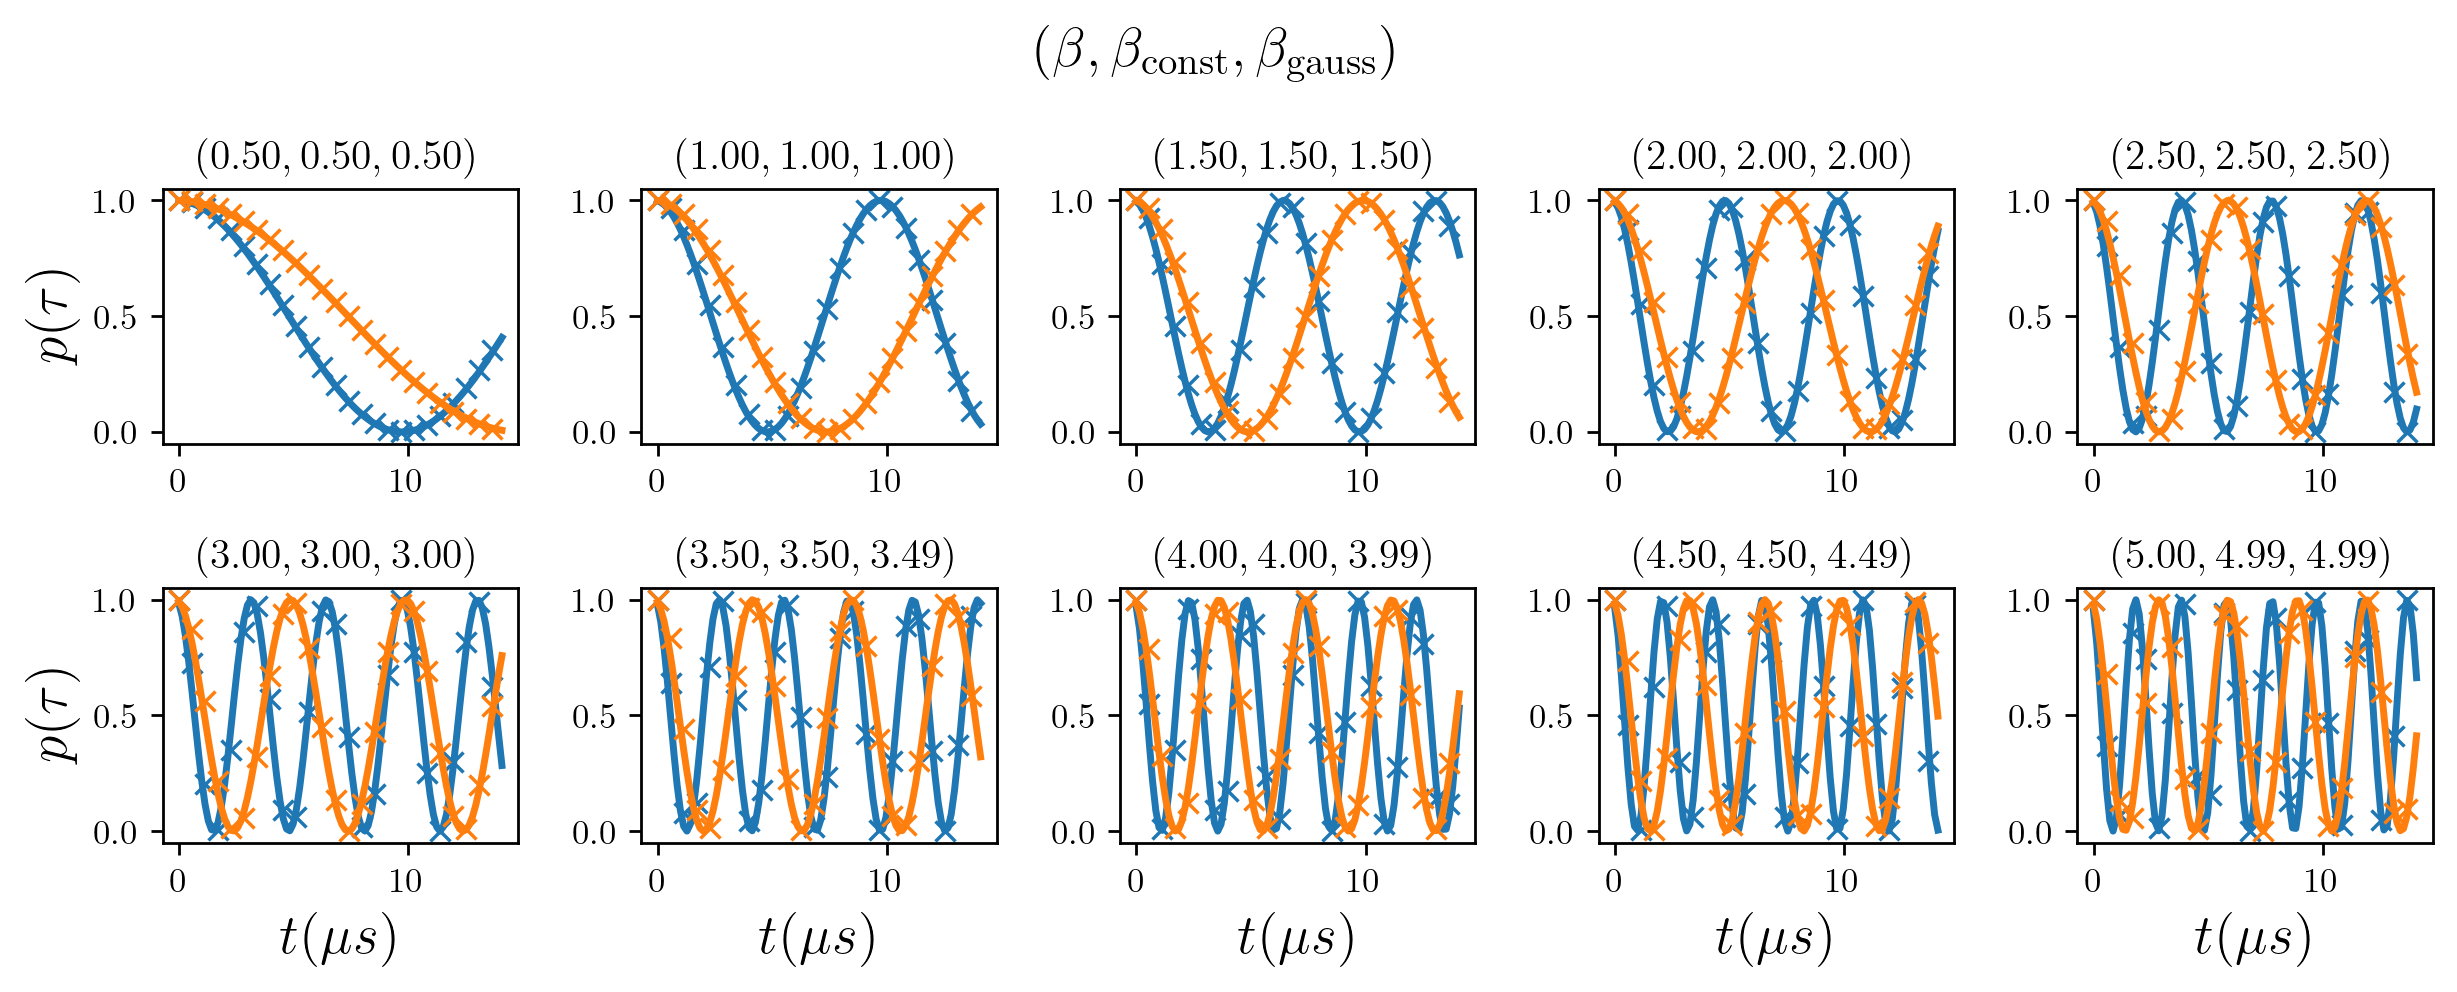

In [26]:
noise_num = len(betas)

beta_const_list = []
beta_gauss_list = []

fig = plt.figure(dpi=250, figsize=(10,4))
plt.suptitle(r"$(\beta,\beta_{\mathrm{const}},\beta_{\mathrm{gauss}})$", fontsize=16)
for i,beta in enumerate(betas):
    ax = fig.add_subplot(2, noise_num//2, i+1)

    # Constant pulse
    plt.plot(tt, ps_const[beta], color=colors[0], lw=2, label='Const')
    (beta_const), cov = spopt.curve_fit(osc_fun, tt, ps_const[beta], p0=(beta))
    plt.plot(tt[::4], osc_fun(tt[::4], beta_const), color=colors[0], marker='x', ls='')

    # Gaussian pulse
    plt.plot(tt, ps_gauss[beta], color=colors[1], lw=2, label='Gauss')
    (beta_gauss), cov = spopt.curve_fit(osc_fun_gauss, tt, ps_gauss[beta], p0=(beta))
    plt.plot(tt[::4], osc_fun_gauss(tt[::4], beta_gauss), color=colors[1], marker='x', ls='')

    ax.set_title('$(%.2f,%.2f,%.2f)$'%(beta,beta_const,beta_gauss), fontsize=12)
    beta_const_list += [beta_const[0]]
    beta_gauss_list += [beta_gauss[0]]
    
    ax.set_ylim(-0.05,1.05)
    if i>noise_num//2-1:
        ax.set_xlabel('$t (\mu s)$', size=16)
    if (i%(noise_num//2))==0:
        ax.set_ylabel(r'$p(\tau)$', size=16)
plt.tight_layout()
plt.show()

# Paper Figure

In [27]:
betas

array([0.5, 1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. ])

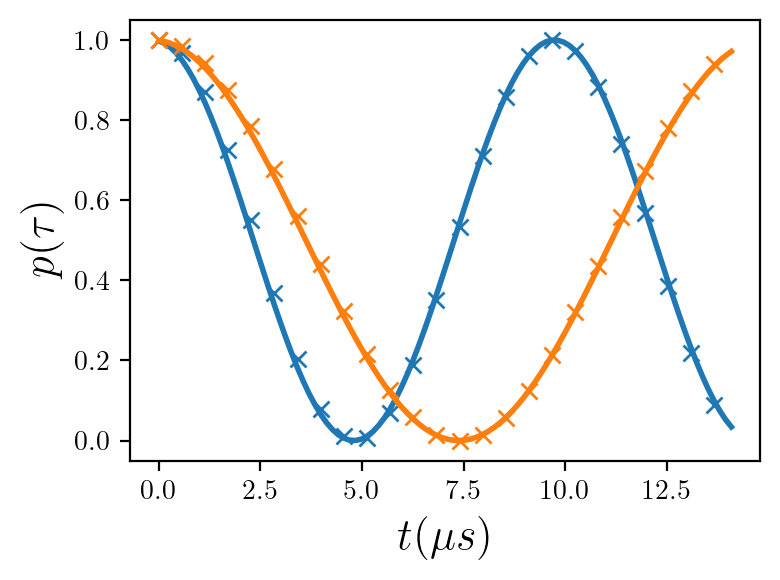

In [28]:
fig = plt.figure(dpi=200, figsize=(4,3))
# plt.suptitle(r"$(\beta,\beta_{\mathrm{const}},\beta_{\mathrm{gauss}})$", fontsize=16)
i = 1
beta = 1

# Constant pulse
plt.plot(tt, ps_const[beta], color=colors[0], lw=2, label='Const')
(beta_const), cov = spopt.curve_fit(osc_fun, tt, ps_const[beta], p0=(beta))
plt.plot(tt[::4], osc_fun(tt[::4], beta_const), color=colors[0], marker='x', ls='')

# Gaussian pulse
plt.plot(tt, ps_gauss[beta], color=colors[1], lw=2, label='Gauss')
(beta_gauss), cov = spopt.curve_fit(osc_fun, tt, ps_gauss[beta], p0=(2*beta/np.pi))
plt.plot(tt[::4], osc_fun(tt[::4], beta_gauss), color=colors[1], marker='x', ls='')

# plt.title('$(%.2f,%.2f,%.2f)$'%(beta,beta_const,beta_gauss), fontsize=12)
plt.ylim(-0.05,1.05)
plt.xlabel('$t (\mu s)$', size=16)
plt.ylabel(r'$p(\tau)$', size=16)
plt.tight_layout()
plt.show()

# Damped oscillations

In [29]:
rho2bloch = lambda rho: np.array([np.trace(rho@pauli) for pauli in paulis])

def Gmat(w, alpha, mu, eta, beta, eps):
    return np.array([[-alpha, -beta, 0],
                     [beta, -mu , -w*(1+eps)],
                     [0,w*(1+eps), -eta]])

In [30]:
gamma = 0.05
lmbda = 0.01
nu    = 0.01
q     = 1

alpha = gamma/2 + lmbda
mu = alpha + nu
eta = gamma + nu
eps   = 0
# c vector
c = np.array([0,0,gamma*(2*q-1)])

In [31]:
def get_Gs(beta):
    Ginv = {}
    eGt  = {}

    for n,g in enumerate(gg):
        G    = Gmat(g, alpha, mu, eta, beta, eps)
        Ginv[n] = scipy.linalg.inv(G)
        eGt[n]  = scipy.linalg.expm(G*ddt)
    return Ginv, eGt

In [32]:
def sim_XrhoX_gauss(rho0, Ginv, eGt):
    vt = np.real(rho2bloch(rho0))
    for n,g in enumerate(gg):
        vt = eGt[n]@vt + (eGt[n]-np.identity(3))@Ginv[n]@c
    return bloch2dm(vt)

In [33]:
def sim_XrhoX_const(rho0, Ginv, eGt):
    v0 = np.real(rho2bloch(rho0))
    vt = eGt@v0 + (eGt-np.identity(3))@Ginv@c
    return bloch2dm(vt)

In [34]:
K = 1000
K_step = 10
kk = np.arange(0,K,K_step)
tt = kk*2*dt

In [35]:
def get_ps(beta):
    Ginv, eGt = get_Gs(beta)
    
    G_pi    = Gmat(np.pi/dt, alpha, mu, eta, beta, eps)
    Ginv_pi = scipy.linalg.inv(G_pi)
    eGt_pi  = scipy.linalg.expm(G_pi*dt)
    
    rho = rho0
    ps_const = [rho[0,0].real]
    for _ in kk[:-1]:
        for _ in range(K_step):
            rho = sim_XrhoX_const(rho, Ginv_pi, eGt_pi)
            rho = Z@rho@Z
            rho = sim_XrhoX_const(rho, Ginv_pi, eGt_pi)
            rho = Z@rho@Z
        ps_const += [rho[0,0].real]

    rho = rho0
    ps_gauss = [rho[0,0].real]
    for _ in kk[:-1]:
        for _ in range(K_step):
            rho = sim_XrhoX_gauss(rho, Ginv, eGt)
            rho = Z@rho@Z
            rho = sim_XrhoX_gauss(rho, Ginv, eGt)
            rho = Z@rho@Z
        ps_gauss += [rho[0,0].real]
    
    return np.array(ps_const), np.array(ps_gauss)

In [36]:
beta = 0.5
ps_const, ps_gauss = get_ps(beta)

In [37]:
betas = np.linspace(0.1,1,10)

ps_const = {}
ps_gauss = {}

for beta in betas:
    ps_const[beta], ps_gauss[beta] = get_ps(beta)

In [40]:
damp_osc_fun = lambda t,b: (1+np.exp(-(3*gamma/4+lmbda/2+nu/2)*t)*np.cos(2*b*t/np.pi))/2

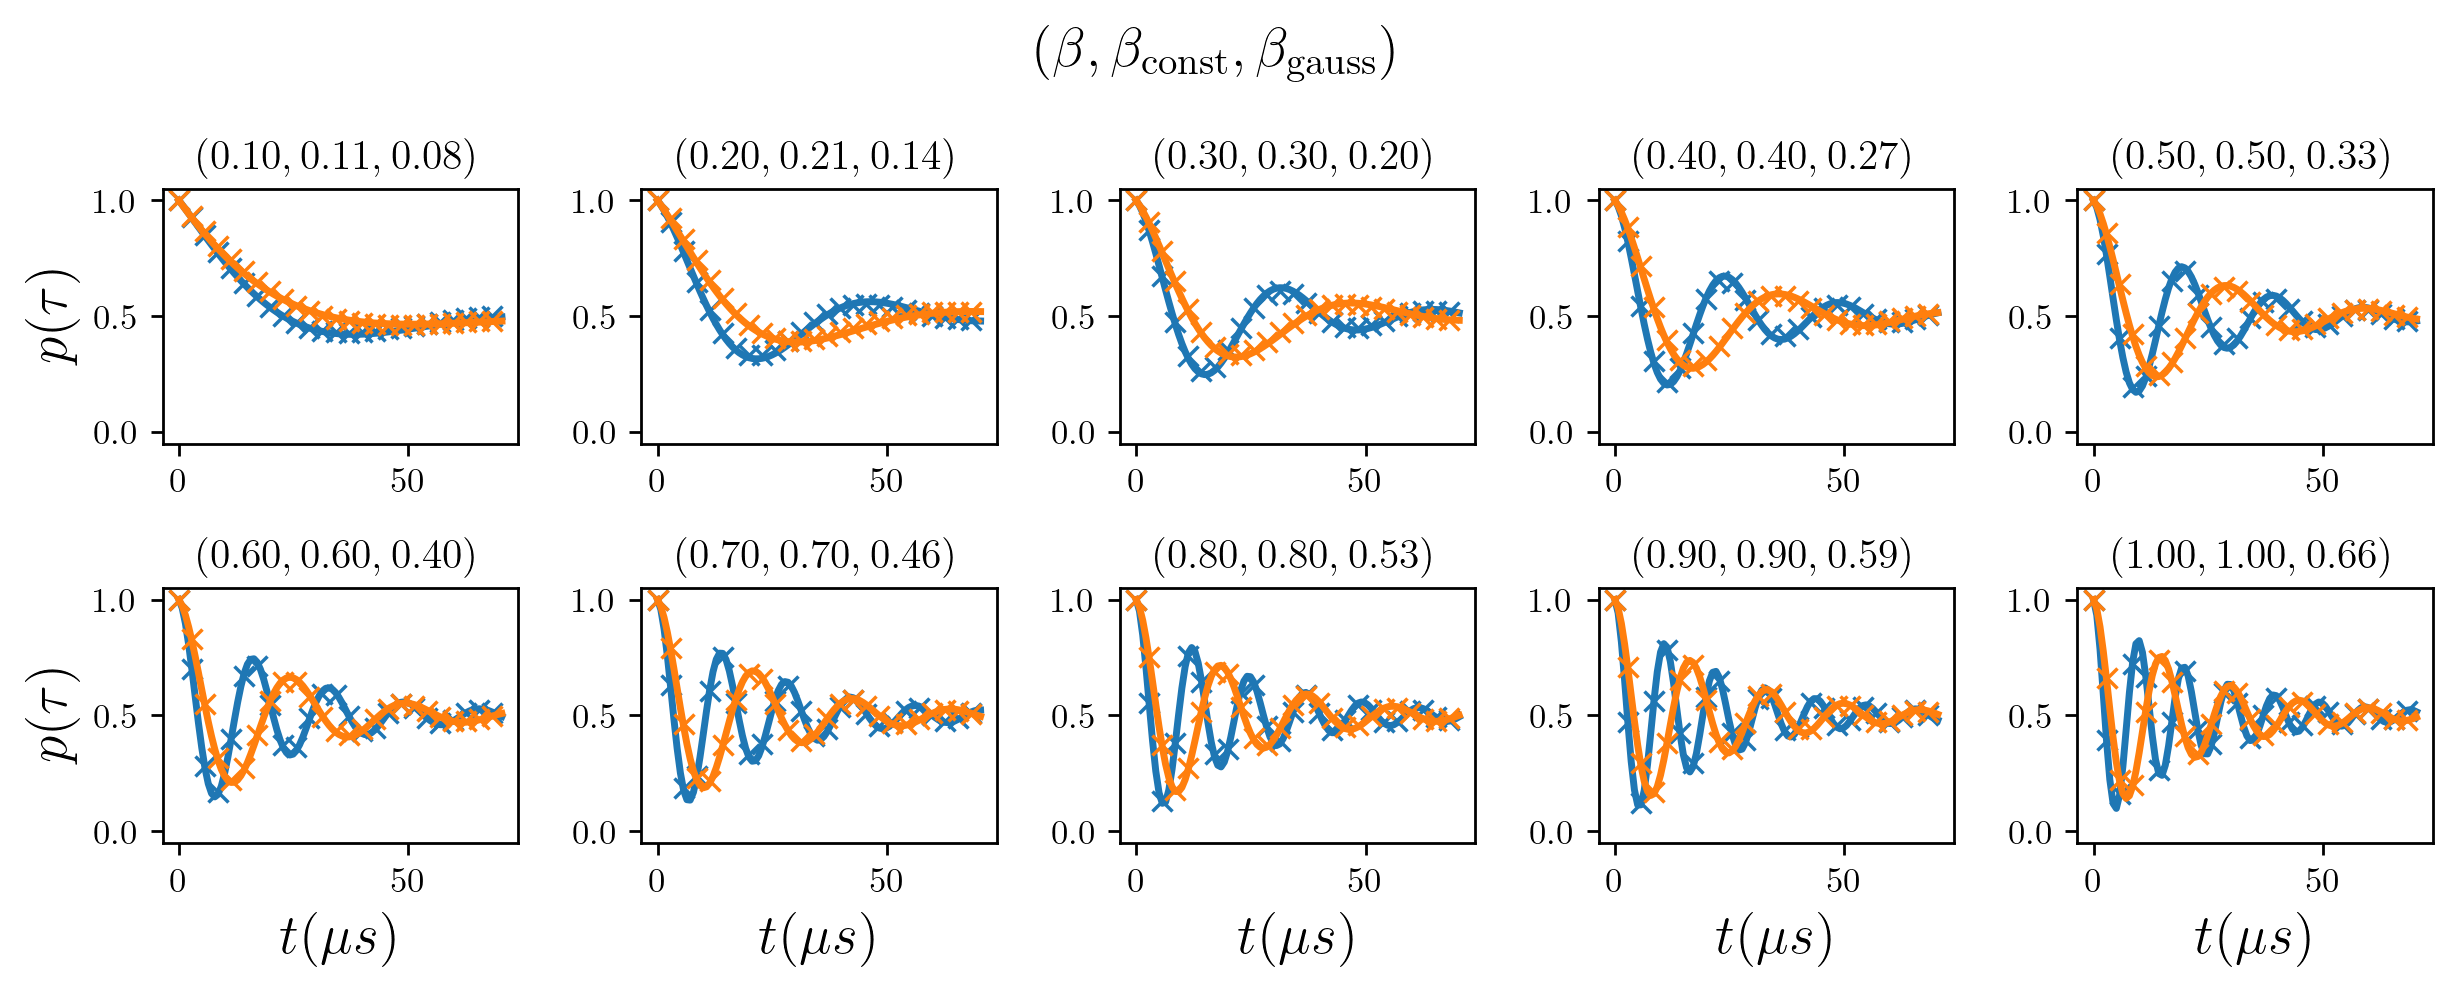

In [41]:
noise_num = len(betas)

beta_const_list = []
beta_gauss_list = []

fig = plt.figure(dpi=250, figsize=(10,4))
plt.suptitle(r"$(\beta,\beta_{\mathrm{const}},\beta_{\mathrm{gauss}})$", fontsize=16)
for i,beta in enumerate(betas):
    ax = fig.add_subplot(2, noise_num//2, i+1)

    # Constant pulse
    plt.plot(tt, ps_const[beta], color=colors[0], lw=2, label='Const')
    (beta_const), cov = spopt.curve_fit(damp_osc_fun, tt, ps_const[beta], p0=(beta))
    plt.plot(tt[::4], damp_osc_fun(tt[::4], beta_const), color=colors[0], marker='x', ls='')

    # Gaussian pulse
    plt.plot(tt, ps_gauss[beta], color=colors[1], lw=2, label='Gauss')
    (beta_gauss), cov = spopt.curve_fit(damp_osc_fun, tt, ps_gauss[beta], p0=(2*beta/np.pi))
    plt.plot(tt[::4], damp_osc_fun(tt[::4], beta_gauss), color=colors[1], marker='x', ls='')

    ax.set_title('$(%.2f,%.2f,%.2f)$'%(beta,beta_const,beta_gauss), fontsize=12)
    beta_const_list += [beta_const[0]]
    beta_gauss_list += [beta_gauss[0]]
    
    ax.set_ylim(-0.05,1.05)
    if i>noise_num//2-1:
        ax.set_xlabel('$t (\mu s)$', size=16)
    if (i%(noise_num//2))==0:
        ax.set_ylabel(r'$p(\tau)$', size=16)
plt.tight_layout()
plt.show()

# Paper Fig

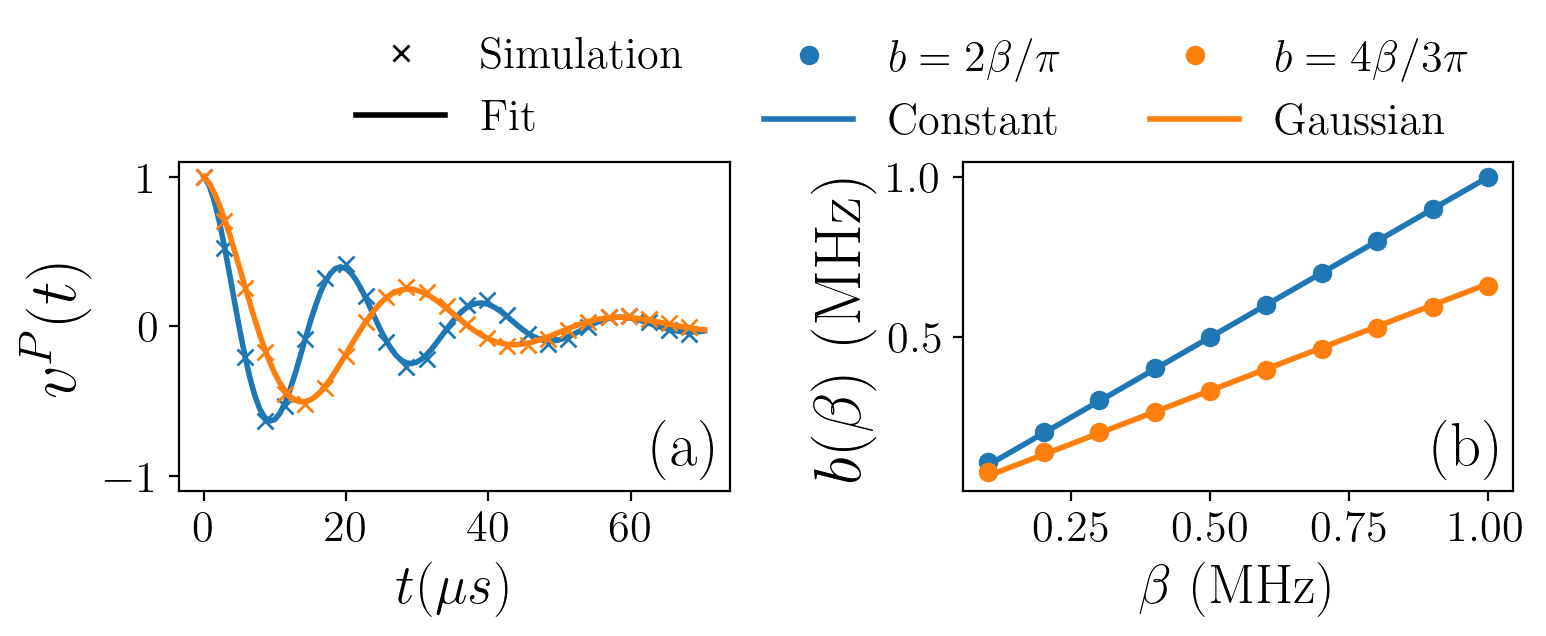

In [70]:
damp_osc_fun = lambda t,b: (1+np.exp(-(3*gamma/4+lmbda/2+nu/2)*t)*np.cos(2*b*t/np.pi))/2

fig = plt.figure(dpi=200, figsize=(8,4))

plt.subplot(121)
# plt.title('$(%.2f,%.2f,%.2f)$'%(beta,beta_const,beta_gauss), fontsize=12)
plt.plot(10,10,ls='', marker='x', label='Simulation', color='k')
plt.plot(10,10,lw=2,label='Fit', color='k')

beta = 0.5
# Constant pulse
(beta_const), cov = spopt.curve_fit(damp_osc_fun, tt, ps_const[beta], p0=(beta))
plt.plot(tt, 2*damp_osc_fun(tt, beta_const)-1, color=colors[0], lw=2)
plt.plot(tt[::4], 2*ps_const[beta][::4]-1, color=colors[0], marker='x', ls='')

# Gaussian pulse
(beta_gauss), cov = spopt.curve_fit(damp_osc_fun, tt, ps_gauss[beta], p0=(2*beta/3))
plt.plot(tt, 2*damp_osc_fun(tt, beta_gauss)-1, color=colors[1], lw=2)
plt.plot(tt[::4], 2*ps_gauss[beta][::4]-1, color=colors[1], marker='x', ls='')

plt.ylim(-1.1,1.1)
plt.xlabel('$t (\mu s)$', size=20)
plt.ylabel(r'$v^P(t)$', size=24)
plt.legend(frameon=False, fontsize=16, bbox_to_anchor=(0.99,1.5), ncol=1)
plt.text(63,-.93,'(a)', fontsize=22)
plt.tick_params(labelsize=16)


plt.subplot(122)
plt.plot(betas, beta_const_list, marker='o', label=r'$b = 2\beta/\pi$', color=colors[0], ls='')
plt.plot(betas, betas, color=colors[0], lw=2, label='Constant')
plt.plot(betas, beta_gauss_list, marker='o', label=r'$b = 4\beta/3\pi$', color=colors[1], ls='')
plt.plot(betas, 2*betas/3, color=colors[1], lw=2, label='Gaussian')

plt.ylabel(r'$b(\beta)$ (MHz)', size=24)
plt.xlabel(r'$\beta$ (MHz)', size=20)
plt.legend(frameon=False, fontsize=16, bbox_to_anchor=(0.99,1.5), ncol=2)
plt.text(.9,0.1,'(b)', fontsize=22)
plt.tick_params(labelsize=16)

plt.tight_layout()
plt.savefig('figures/gaussian_vs_const_pulse.pdf', bbox_inches='tight')
plt.show()